# **WARNING**

**THIS NOTEBOOK RUNS THE MODELS.**

**DO NOT 'RUN ALL' UNLESS YOU ARE READY FOR LONG RUN TIMES AND PLEASE DO NOT OVERWRITE MODEL DATA UNLESS EXPERIMENTING**

# Imports

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Biggest Problem

How to handle so many categories...

- have routes instead of each station being separate

- lower weather data to a normalized vector of how likely it is to cause a delay

- remove delay types and have the models predict delays based off of past data and weather correlations

# Model Ideas

- XGBoost
    - Simple, lightweight, fast

- XGBoost Ensemble
    - Since it's so fast we train 10-50 different XGB and have them "vote"

- MLP
    - Probably not gonna work very well

- GNN
    - The libraries for this are a bit difficult to work with
    - Best current option for handling so many diminsions

# Import/Prepare Data

In [90]:
#TODO
# Data things from data/processed
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from src.data_processing import merged_dataset

df = merged_dataset()

In [91]:
X = df
y = df["minutes_late"]

y.isna().sum()

df.dtypes

train             string[python]
depart_station          category
arrive_station          category
minutes_late             float32
DATE              datetime64[ns]
PRCP                     float32
SNOW                     float32
SNWD                     float32
TMAX                     float32
TMIN                     float32
PRCP_TOTAL               float32
TAVG                     float32
dtype: object

In [ ]:
# Feature engineering
X['DATE'] = pd.to_datetime(X['DATE'])

X['year']  = X['DATE'].dt.year
X['month'] = X['DATE'].dt.month
X['day']   = X['DATE'].dt.day
X['dow']   = X['DATE'].dt.dayofweek

df['station_pair'] = (
    df['depart_station'].astype(str)
    + '→'
    + df['arrive_station'].astype(str)
)

X = X.drop(columns=['DATE', 'minutes_late'])

mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Columns to encode
cat_cols = ['train', 'depart_station', 'arrive_station', 'station_pair']

# Mean encoding using train only
for col in cat_cols:
    means = y_train.groupby(X_train[col]).mean()

    X_train[col + '_mean'] = X_train[col].map(means)
    X_test[col + '_mean']  = X_test[col].map(means)

# Drop original categorical columns
X_train.drop(columns=cat_cols, inplace=True)
X_test.drop(columns=cat_cols, inplace=True)

# Handle unseen categories just in case
X_train.fillna(y_train.mean(), inplace=True)
X_test.fillna(y_train.mean(), inplace=True)

# Handle outliers
y_train = y_train.clip(upper=y_train.quantile(0.99))

X_train.head()


C:\Users\mypie\AppData\Local\Temp\ipykernel_11968\2521379663.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = y_train.groupby(X_train[col]).mean()
C:\Users\mypie\AppData\Local\Temp\ipykernel_11968\2521379663.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = y_train.groupby(X_train[col]).mean()


,PRCP,SNOW,SNWD,TMAX,TMIN,PRCP_TOTAL,TAVG,year,month,day,dow,train_mean,depart_station_mean,arrive_station_mean,station_pair_mean
1717,0.11,0.0,0.0,38.0,32.0,0.11,35.0,2010,3,4,3,16.354431,14.360410,16.121719,14.824128
152225,0.00,0.0,0.0,66.0,43.0,0.00,54.5,2019,4,25,3,10.262820,11.252671,11.328246,10.696678
186663,0.00,0.0,0.0,65.0,49.0,0.00,57.0,2022,9,30,4,16.028038,11.252671,16.779821,16.892086
116915,0.68,0.0,0.0,93.0,65.0,0.68,79.0,2017,6,14,2,10.759420,11.252671,11.328246,10.696678
15599,0.00,0.0,13.0,31.0,9.0,0.00,20.0,2011,1,14,4,12.533058,11.252671,11.328246,10.696678


In [93]:
# Verify that indexes are looking the same, which they are
y_train.head()

1717       6.0
152225     6.0
186663    17.0
116915    10.0
15599      7.0
Name: minutes_late, dtype: float32

# Random Forest

In [94]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions and evaluate
predictions = rf_model.predict(X_test)
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions):.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, predictions)):.2f} minutes")
print(f"R-squared Score: {r2_score(y_test, predictions):.2f}")
mape = mean_absolute_percentage_error(y_test, predictions) * 100
print(f"MAPE: {mape:.2f}%")

Mean Absolute Error: 5.99 minutes
Root Mean Squared Error (RMSE): 10.59 minutes
R-squared Score: 0.08
MAPE: 50.81%


# XGB First

In [95]:
#TODO
# XGB Code

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

xgb_model.fit(X_train, y_train)

predictions = xgb_model.predict(X_test)

print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions):.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, predictions)):.2f} minutes")
print(f"R-squared Score: {r2_score(y_test, predictions):.2f}")
mape = mean_absolute_percentage_error(y_test, predictions) * 100
print(f"MAPE: {mape:.2f}%")

Mean Absolute Error: 5.73 minutes
Root Mean Squared Error (RMSE): 10.60 minutes
R-squared Score: 0.08
MAPE: 46.50%


In [96]:
# Save model separately with .json file in src\Models\XGB

## XGB and RF Analysis/Visuals

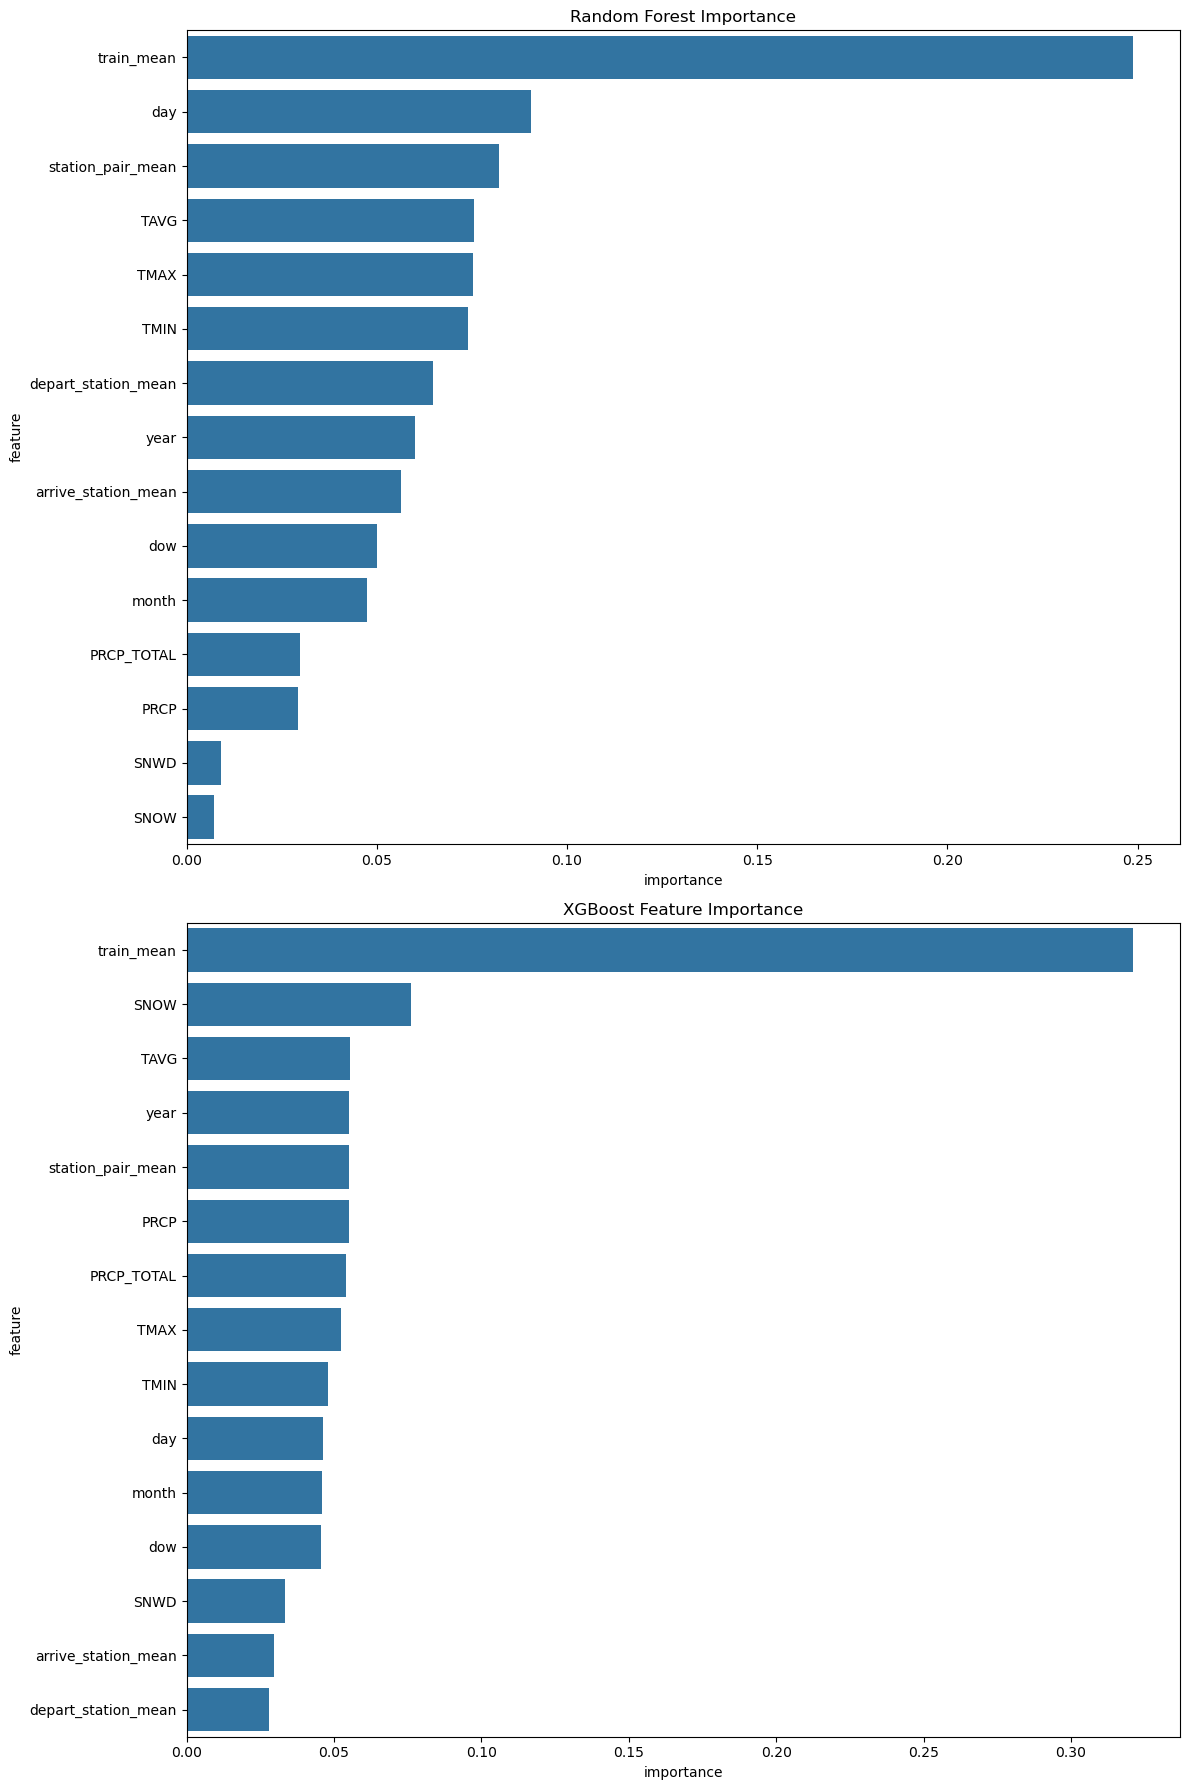

In [109]:
#TODO
# Graphs and stuff, probably some training losses and precision/recall goodies

rf_importance = rf_model.feature_importances_
rf_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_importance
}).sort_values(by="importance", ascending=False)

xgb_importance = xgb_model.feature_importances_
xgb_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_importance
}).sort_values(by="importance", ascending=False)


# Plots
fig, axes = plt.subplots(2, 1, figsize=(12, 18))

sns.barplot(x="importance", y="feature", data=rf_df, ax=axes[0])
axes[0].set_title("Random Forest Importance")

sns.barplot(x="importance", y="feature", data=xgb_df, ax=axes[1])
axes[1].set_title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

# XGB Ensemble

In [98]:
#TODO
# Same thing only different

In [99]:
# Save models separately with .json file in src\Models\XGB_Ensemble

## Ensemble Analysis/Visuals

In [100]:
# Graphs and stuffs

# MLP

In [101]:
#TODO
# This one is less likely to work due to the dimension problem, but I'll make a custom class to plug and play with optuna

In [102]:
# Save model weights with .pkl in src\Models\MLP

## MLP Visuals and Analysis

In [103]:
# Getting kind of tedious now. Might make some custom callable functions for graphing

# GNN

### Build Graph

In [104]:
#TODO
# Ensure proper libraries and dependencies are working together 
# Nodes are stations
# Edges are neighbors
# Features are probably same line and KNN

### Build Model

In [105]:
#TODO
# yes

### Train

In [106]:
#TODO
# Also yes

In [107]:
# Save with .pth file in src\Models\GNN

## GNN Visualize and Analysis

In [108]:
#TODO
# Pretty Pictures